# Appendix A: Review of Topology

**Source Span.** *Introduction to Smooth Manifolds*, Appendix A, printed pages 596-616. I used the text extraction window `pdftotext -f 614 -l 634` as a source map, with a focused reread of the construction, compactness, homotopy, and covering sections.

**Chapter goal.** Build a working topological vocabulary for smooth manifolds: what data defines open sets, how maps are tested, which separation/countability/local hypotheses remove pathologies, how standard constructions change the test for continuity, and how compactness, homotopy, fundamental groups, and covering spaces become reusable invariants.

This notebook is intentionally computational even though Appendix A is a review. The finite examples make the definitions executable. The metric and circle examples show how the same tests behave in the spaces that later become manifolds.


## Visual Storyboard

The storyboard below turns the appendix into inspectable models rather than a list of definitions.

| Topic anchor | Representation | Artifact | Inspection target | Check |
| --- | --- | --- | --- | --- |
| Open, closed, interior, closure, boundary | finite topology lattice | `topology-operations-lattice.png` | see interior/exterior/boundary as unions of open sets | finite topology axioms and boundary identities |
| Continuity, sequences, Hausdorff, countability | finite predicates and convergence table | `finite-topology-sets.csv` | compare trivial, finite non-Hausdorff, and discrete behavior | inverse-image and uniqueness assertions |
| Subspace/product/disjoint union/quotient | construction flow graph | `topology-constructions-flow.png` | remember which map gives the universal continuity test | topology constructors satisfy their characteristic tests |
| Quotient maps | endpoint quotient saturation diagram | `quotient-saturated-open-diagnostics.png` | distinguish open subsets of the domain from open subsets of the quotient | saturated-open diagnostics |
| Connectedness and local path-connectedness | graph models of components and paths | `connectedness-components-graph.png` | see when path components merge under a bridge | NetworkX component counts and product/quotient checks |
| Compactness, properness, local compactness | finite-subcover and exhaustion model | `compactness-finite-subcover-model.png` | watch compactness replace an arbitrary cover by finite data | cover, exhaustion, and properness witnesses |
| Homotopy, pi_1, covering maps | winding/lift and sheet simulation | `loop-winding-and-covering-lift.png`, `circle-covering-lift-simulator.html` | read winding as endpoint displacement of a lift | winding additivity, closed-lift criterion, projection residual |


In [1]:
from pathlib import Path
import itertools
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

def locate_book_root() -> Path:
    here = Path.cwd().resolve()
    candidates = [here, *here.parents, here / "Introduction-to-Smooth-Manifolds"]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not locate the Introduction-to-Smooth-Manifolds book root.")

BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "appendix-a-review-of-topology"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})

artifact_paths: list[Path] = []
check_paths: list[Path] = []
table_paths: list[Path] = []


## Library Routing

Appendix A is not a mesh or curvature chapter. The useful computational objects are finite topologies, graph models of paths and components, interval covers, and circle covering maps. NetworkX is used when connectivity or proof dependence is the concept; Plotly is used for the covering-space lift because rotation and sheet height are clearer interactively; Matplotlib is used for durable static diagrams.


In [2]:
routing_rows = [
    {
        "concept": "finite topology operations",
        "representation": "sets, subset lattice, exact predicates",
        "library": "Python frozenset plus Matplotlib",
        "why": "the topology axioms, interior, closure, boundary, and inverse-image continuity are exact finite operations",
        "fallback": "plain tables if plotting is unavailable",
    },
    {
        "concept": "construction characteristic properties",
        "representation": "directed dependency graph",
        "library": "NetworkX plus Matplotlib",
        "why": "subspace, product, disjoint union, and quotient topologies are best remembered by their universal test maps",
        "fallback": "markdown table of tests",
    },
    {
        "concept": "quotient map diagnostics",
        "representation": "saturated subsets for an endpoint quotient",
        "library": "NumPy plus Matplotlib",
        "why": "the interval-to-circle quotient has a visible seam where non-saturated opens fail",
        "fallback": "finite quotient topology table",
    },
    {
        "concept": "connected and path-connected models",
        "representation": "graph components for 1-complex-like spaces",
        "library": "NetworkX",
        "why": "locally path-connected examples reduce path components to graph components in an inspectable finite model",
        "fallback": "component table",
    },
    {
        "concept": "compactness and proper maps",
        "representation": "finite subcover, compact exhaustion, sequence witness",
        "library": "NumPy, Pandas, Matplotlib",
        "why": "compactness is a finite-extraction principle and properness is a compact-preimage test",
        "fallback": "CSV ledger only",
    },
    {
        "concept": "fundamental group and coverings",
        "representation": "winding numbers and lifted paths",
        "library": "Plotly, NumPy, Matplotlib",
        "why": "lifting a circle loop to a line turns homotopy class into endpoint displacement",
        "fallback": "static winding plot",
    },
]

storyboard = [
    {
        "concept": "open/closed/interior/closure/boundary",
        "artifact": "figures/topology-operations-lattice.png",
        "inspection_target": "open-set containment determines interior and exterior; closure is dual by complements",
        "validation": "finite topology axioms, boundary equals closure(A) intersect closure(X-A)",
    },
    {
        "concept": "standard topology constructions",
        "artifact": "figures/topology-constructions-flow.png",
        "inspection_target": "each construction is controlled by a specific test map",
        "validation": "subspace/product/disjoint-union/quotient constructors produce topologies",
    },
    {
        "concept": "quotient topology and saturated opens",
        "artifact": "figures/quotient-saturated-open-diagnostics.png",
        "inspection_target": "a seam-crossing open arc needs both endpoint neighborhoods before projection",
        "validation": "open saturated candidates project open; non-saturated endpoint candidates fail",
    },
    {
        "concept": "connected/path-connected/local path-connected",
        "artifact": "figures/connectedness-components-graph.png",
        "inspection_target": "a bridge merges path components in locally path-connected graph models",
        "validation": "NetworkX component counts and product/quotient connectedness",
    },
    {
        "concept": "compactness/properness/local compactness",
        "artifact": "figures/compactness-finite-subcover-model.png",
        "inspection_target": "compactness turns a cover into a finite certificate and local compactness into compact exhaustions",
        "validation": "dense-grid cover test, exhaustion nesting, nonproper inclusion witness",
    },
    {
        "concept": "homotopy/fundamental group/covering maps",
        "artifact": "figures/loop-winding-and-covering-lift.png",
        "inspection_target": "pi_1(S1) records lifted endpoint displacement; finite covers close only on multiples of sheet number",
        "validation": "winding additivity, reverse loop, closed-lift criterion, projection residual",
    },
]

routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
storyboard_path = save_json(
    {
        "source_span": "Appendix A, printed pages 596-616; extraction window pages 614-634",
        "storyboard": storyboard,
        "library_routing": routing_rows,
    },
    CHECKS / "visual-storyboard.json",
)
table_paths.append(routing_path)
check_paths.append(storyboard_path)

display(pd.DataFrame(routing_rows))


,concept,representation,library,why,fallback
0,finite topology operations,"sets, subset lattice, exact predicates",Python frozenset plus Matplotlib,"the topology axioms, interior, closure, bounda...",plain tables if plotting is unavailable
1,construction characteristic properties,directed dependency graph,NetworkX plus Matplotlib,"subspace, product, disjoint union, and quotien...",markdown table of tests
2,quotient map diagnostics,saturated subsets for an endpoint quotient,NumPy plus Matplotlib,the interval-to-circle quotient has a visible ...,finite quotient topology table
3,connected and path-connected models,graph components for 1-complex-like spaces,NetworkX,locally path-connected examples reduce path co...,component table
4,compactness and proper maps,"finite subcover, compact exhaustion, sequence ...","NumPy, Pandas, Matplotlib",compactness is a finite-extraction principle a...,CSV ledger only
5,fundamental group and coverings,winding numbers and lifted paths,"Plotly, NumPy, Matplotlib",lifting a circle loop to a line turns homotopy...,static winding plot


## Computational Translation Guide

A topology is not a distance function. It is a rule for which subsets count as open. In a finite model we can store that rule literally as a family of subsets. In a metric model, the rule is implicit: a set is open when every point has a small ball still inside it.

The appendix uses the same pattern repeatedly:

- A topological property is usually tested by open sets or by closed sets.
- A continuous map is tested backwards, by inverse images of open sets.
- A subspace, product, disjoint union, or quotient topology is the weakest or strongest topology that makes a characteristic continuity test work.
- Countability, Hausdorffness, local path-connectedness, and local compactness are hypotheses that make the naive geometric pictures reliable.
- Homotopy and coverings translate loops into algebraic data: path classes, induced homomorphisms, and lifted endpoints.


## Finite Topologies: Interior, Closure, Boundary, Continuity, Sequences

The following finite space is deliberately non-Hausdorff. That makes it useful: it shows which familiar facts require separation hypotheses. The set `A = {q, s}` is not open, its exterior is a visible open region, and its boundary can be checked exactly.


,subset,open,closed,is_A,interior_of_A,closure_of_A,boundary_of_A
0,{},True,True,False,True,False,False
1,{p},True,False,False,False,False,False
2,{q},False,False,False,False,False,False
3,{r},False,False,False,False,False,False
4,{s},False,True,False,False,False,False
5,"{p,q}",True,False,False,False,False,False
6,"{p,r}",True,False,False,False,False,False
7,"{p,s}",False,False,False,False,False,False
8,"{q,r}",False,False,False,False,False,False
9,"{q,s}",False,True,True,False,True,True


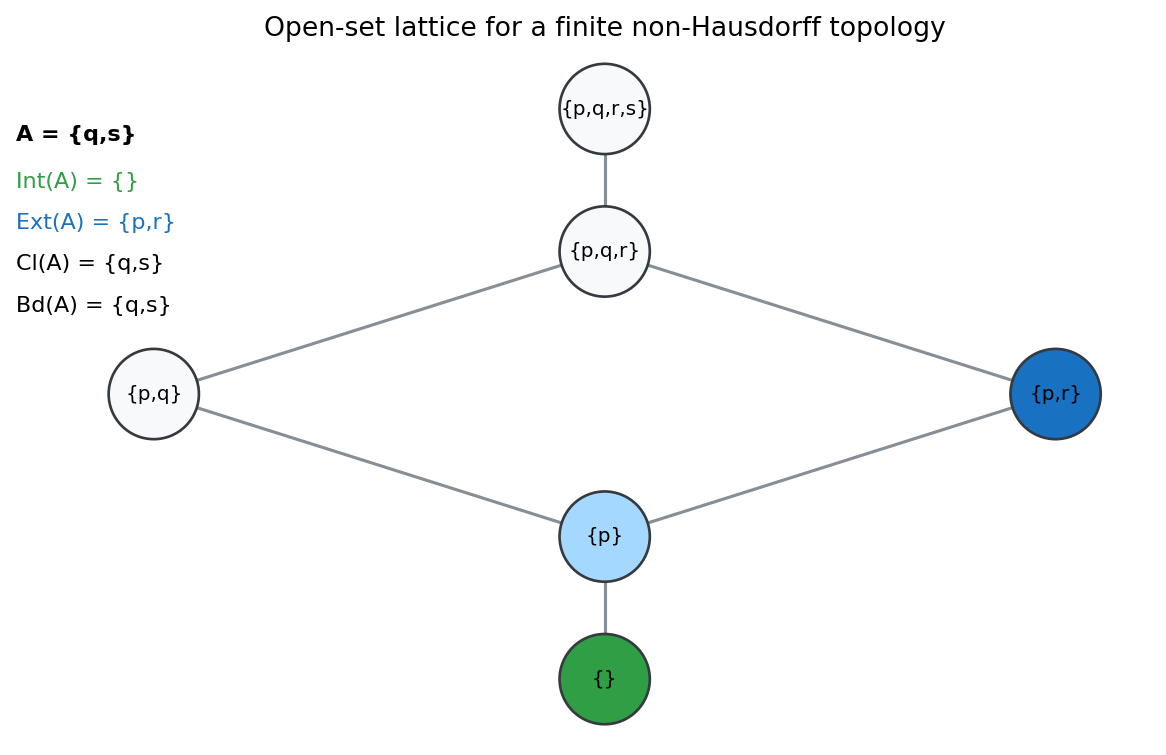

`finite-topology-checks.json`: `{'space': ['p', 'q', 'r', 's'], 'topology_size': 6, 'topology_axioms_hold': True, 'A': '{q,s}', 'interior_A': '{}', 'closure_A': '{q,s}', 'exterior_A': '{p,r}', 'boundary_A': '{q,s}', 'boundary_equals_closure_intersection_complement_closure': True, 'finite_space_second_countable': True, 'nonhausdorff_example': True, 'discrete_space_hausdorff': True, 'open_indicator_to_sierpinski_continuous': True, 'nonopen_indicator_to_sierpinski_continuous': False, 'trivial_eventual_tail_0_limits': ['0', '1'], 'discrete_eventual_tail_0_limits': ['0']}`

In [3]:
def frozen_set(items) -> frozenset:
    return frozenset(items)

def powerset(items):
    items = list(items)
    for r in range(len(items) + 1):
        for combo in itertools.combinations(items, r):
            yield frozenset(combo)

def set_label(S: frozenset) -> str:
    if not S:
        return "{}"
    return "{" + ",".join(sorted(S)) + "}"

def normalize_topology(topology) -> set[frozenset]:
    return {frozenset(U) for U in topology}

def is_topology(X: frozenset, topology) -> bool:
    T = normalize_topology(topology)
    if frozenset() not in T or X not in T:
        return False
    opens = list(T)
    for family in powerset(opens):
        union = frozenset().union(*family) if family else frozenset()
        if union not in T:
            return False
    for U in opens:
        for V in opens:
            if (U & V) not in T:
                return False
    return True

def closed_sets(X: frozenset, topology) -> set[frozenset]:
    return {X - U for U in normalize_topology(topology)}

def interior(A: frozenset, topology) -> frozenset:
    contained = [U for U in normalize_topology(topology) if U <= A]
    return frozenset().union(*contained) if contained else frozenset()

def closure(X: frozenset, A: frozenset, topology) -> frozenset:
    containing = [C for C in closed_sets(X, topology) if A <= C]
    return frozenset.intersection(*containing) if containing else X

def exterior(X: frozenset, A: frozenset, topology) -> frozenset:
    return interior(X - A, topology)

def boundary(X: frozenset, A: frozenset, topology) -> frozenset:
    return X - interior(A, topology) - exterior(X, A, topology)

def neighborhoods(point: str, topology) -> list[frozenset]:
    return sorted([U for U in normalize_topology(topology) if point in U], key=lambda U: (len(U), sorted(U)))

def is_hausdorff(X: frozenset, topology) -> bool:
    T = list(normalize_topology(topology))
    for p, q in itertools.combinations(X, 2):
        separated = any(p in U and q in V and U.isdisjoint(V) for U in T for V in T)
        if not separated:
            return False
    return True

def is_continuous_map(X, TX, Y, TY, mapping: dict[str, str]) -> bool:
    TX = normalize_topology(TX)
    for V in normalize_topology(TY):
        preimage = frozenset(x for x in X if mapping[x] in V)
        if preimage not in TX:
            return False
    return True

def eventually_constant_limits(X, topology, tail_value: str) -> list[str]:
    limits = []
    for candidate in sorted(X):
        if all(tail_value in U for U in neighborhoods(candidate, topology)):
            limits.append(candidate)
    return limits

X = frozenset({"p", "q", "r", "s"})
T = normalize_topology([
    frozenset(),
    {"p"},
    {"p", "q"},
    {"p", "r"},
    {"p", "q", "r"},
    X,
])
A = frozenset({"q", "s"})

int_A = interior(A, T)
cl_A = closure(X, A, T)
ext_A = exterior(X, A, T)
bd_A = boundary(X, A, T)
cl_complement = closure(X, X - A, T)

sierpinski = frozenset({"0", "1"})
T_sierpinski = normalize_topology([frozenset(), {"1"}, sierpinski])
open_indicator = {x: ("1" if x in frozenset({"p", "q"}) else "0") for x in X}
nonopen_indicator = {x: ("1" if x in frozenset({"q", "s"}) else "0") for x in X}

trivial_T = normalize_topology([frozenset(), sierpinski])
discrete_T = normalize_topology(powerset(sierpinski))

finite_rows = []
for subset in sorted(powerset(X), key=lambda U: (len(U), sorted(U))):
    finite_rows.append({
        "subset": set_label(subset),
        "open": subset in T,
        "closed": subset in closed_sets(X, T),
        "is_A": subset == A,
        "interior_of_A": subset == int_A,
        "closure_of_A": subset == cl_A,
        "boundary_of_A": subset == bd_A,
    })
finite_table = pd.DataFrame(finite_rows)
finite_table_path = save_csv(finite_rows, TABLES / "finite-topology-sets.csv")
table_paths.append(finite_table_path)

finite_checks = {
    "space": sorted(X),
    "topology_size": len(T),
    "topology_axioms_hold": is_topology(X, T),
    "A": set_label(A),
    "interior_A": set_label(int_A),
    "closure_A": set_label(cl_A),
    "exterior_A": set_label(ext_A),
    "boundary_A": set_label(bd_A),
    "boundary_equals_closure_intersection_complement_closure": bd_A == (cl_A & cl_complement),
    "finite_space_second_countable": True,
    "nonhausdorff_example": not is_hausdorff(X, T),
    "discrete_space_hausdorff": is_hausdorff(sierpinski, discrete_T),
    "open_indicator_to_sierpinski_continuous": is_continuous_map(X, T, sierpinski, T_sierpinski, open_indicator),
    "nonopen_indicator_to_sierpinski_continuous": is_continuous_map(X, T, sierpinski, T_sierpinski, nonopen_indicator),
    "trivial_eventual_tail_0_limits": eventually_constant_limits(sierpinski, trivial_T, "0"),
    "discrete_eventual_tail_0_limits": eventually_constant_limits(sierpinski, discrete_T, "0"),
}

assert finite_checks["topology_axioms_hold"]
assert finite_checks["boundary_equals_closure_intersection_complement_closure"]
assert finite_checks["open_indicator_to_sierpinski_continuous"]
assert not finite_checks["nonopen_indicator_to_sierpinski_continuous"]
assert len(finite_checks["trivial_eventual_tail_0_limits"]) == 2
assert finite_checks["discrete_eventual_tail_0_limits"] == ["0"]

finite_checks_path = save_json(finite_checks, CHECKS / "finite-topology-checks.json")
check_paths.append(finite_checks_path)

H = nx.DiGraph()
for U in T:
    H.add_node(U)
for U in T:
    for V in T:
        if U < V and not any(U < W < V for W in T):
            H.add_edge(U, V)

rank_groups: dict[int, list[frozenset]] = {}
for U in T:
    rank_groups.setdefault(len(U), []).append(U)
pos = {}
for rank, members in rank_groups.items():
    members = sorted(members, key=lambda U: sorted(U))
    x_positions = np.linspace(-1.8, 1.8, len(members)) if len(members) > 1 else [0.0]
    for x_pos, U in zip(x_positions, members):
        pos[U] = (x_pos, rank)

node_colors = []
for U in H.nodes:
    if U == int_A:
        node_colors.append("#2f9e44")
    elif U == ext_A:
        node_colors.append("#1971c2")
    elif U <= A:
        node_colors.append("#9be7a1")
    elif U <= (X - A):
        node_colors.append("#a5d8ff")
    else:
        node_colors.append("#f8f9fa")

fig, ax = plt.subplots(figsize=(8.8, 5.6))
nx.draw_networkx_edges(H, pos, ax=ax, arrows=False, width=1.4, edge_color="#868e96")
nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors, node_size=1650, edgecolors="#343a40", linewidths=1.2)
nx.draw_networkx_labels(H, pos, labels={U: set_label(U) for U in H.nodes}, ax=ax, font_size=9)
ax.set_title("Open-set lattice for a finite non-Hausdorff topology")
ax.text(-2.35, 3.78, f"A = {set_label(A)}", fontsize=10, weight="bold")
ax.text(-2.35, 3.45, f"Int(A) = {set_label(int_A)}", color="#2f9e44")
ax.text(-2.35, 3.16, f"Ext(A) = {set_label(ext_A)}", color="#1971c2")
ax.text(-2.35, 2.87, f"Cl(A) = {set_label(cl_A)}")
ax.text(-2.35, 2.58, f"Bd(A) = {set_label(bd_A)}")
ax.set_axis_off()
topology_lattice_path = save_matplotlib(fig, FIGURES / "topology-operations-lattice.png")
plt.close(fig)
artifact_paths.append(topology_lattice_path)

display(finite_table)
display_artifact(topology_lattice_path, width=760)
display(Markdown(f"`finite-topology-checks.json`: `{finite_checks}`"))


The Sierpinski-space test is worth remembering: a function into `{0,1}` with `{1}` open is continuous exactly when the subset where it equals `1` is open. That is why inverse images, not pointwise formulas, are the native language of continuity here.

The sequence check also shows the role of Hausdorffness. In the trivial topology, an eventually constant sequence can converge to every point. In a discrete space it converges only to its eventual value.


## Subspaces, Products, Disjoint Unions, and Quotients

Each construction changes the continuity test in a controlled way.

- Subspace: test after composing with the inclusion.
- Product: test all coordinate projections.
- Disjoint union: test each tagged summand.
- Quotient: test after precomposing with the projection.

The graph below is a proof-reading scaffold for these characteristic properties and for the open/closed-map criteria that often certify quotient maps, embeddings, and homeomorphisms.


,subspace_topology_is_topology,product_topology_is_topology,disjoint_union_topology_is_topology,quotient_topology_is_topology,subspace_open_count,product_open_count,disjoint_union_open_count,quotient_open_count,quotient_opens
0,True,True,True,True,4,9,12,4,"[{}, {alpha}, {alpha,beta}, {alpha,beta,sigma}]"


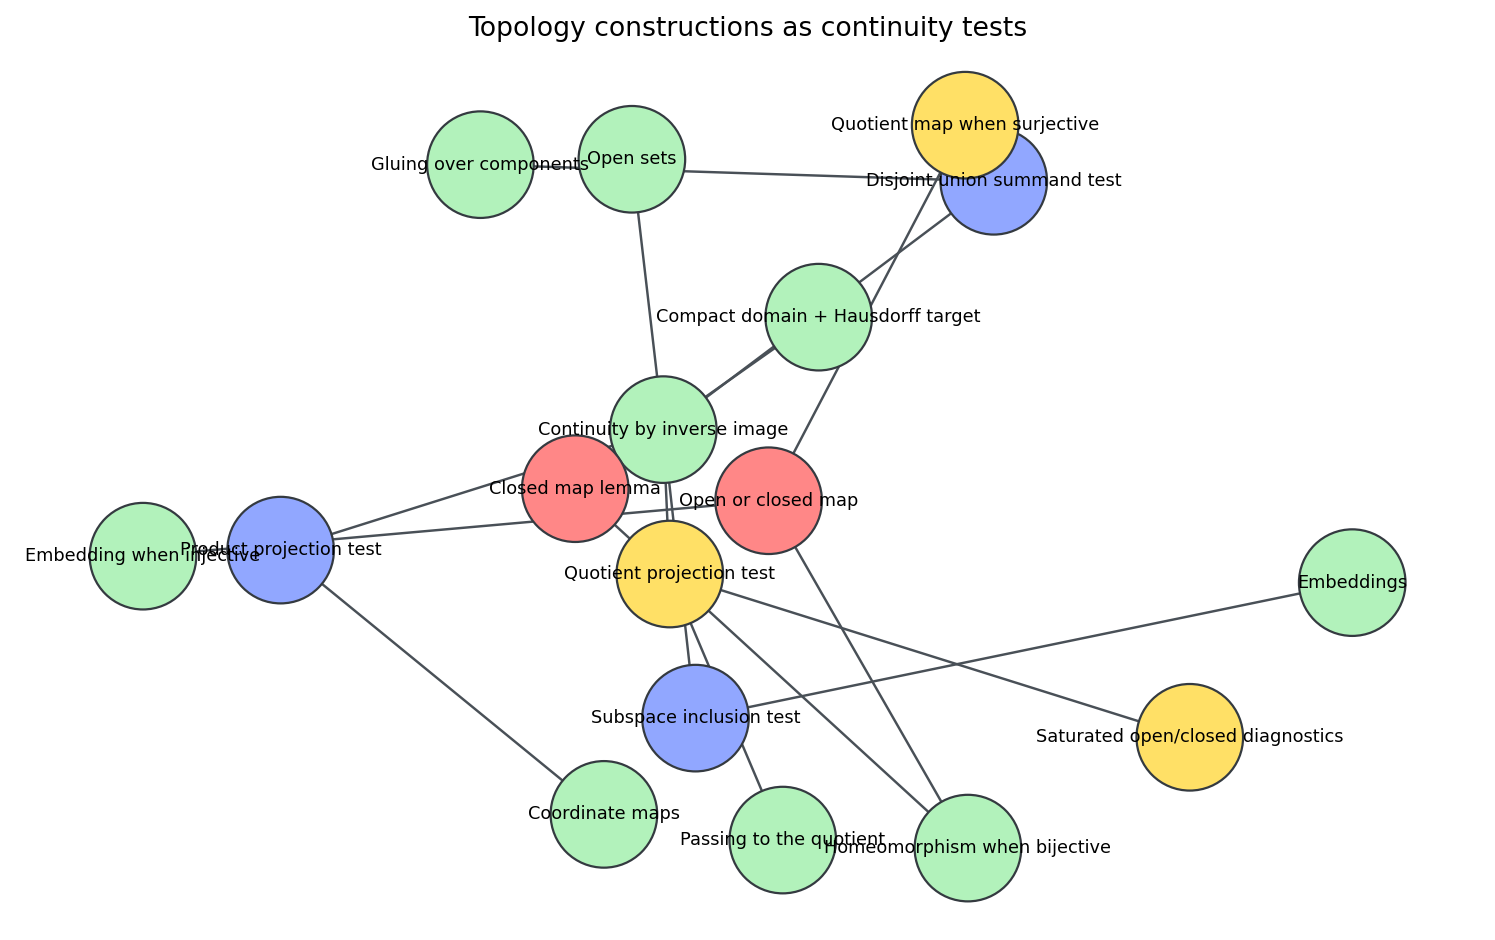

In [4]:
def subspace_topology(S: frozenset, topology) -> set[frozenset]:
    return {U & S for U in normalize_topology(topology)}

def product_topology(X1, T1, X2, T2) -> set[frozenset]:
    product_points = frozenset((x, y) for x in X1 for y in X2)
    basis = [frozenset((x, y) for x in U for y in V) for U in normalize_topology(T1) for V in normalize_topology(T2)]
    generated = set()
    for family in powerset(basis):
        generated.add(frozenset().union(*family) if family else frozenset())
    assert product_points in generated
    return generated

def disjoint_union_topology(summands: dict[str, tuple[frozenset, set[frozenset]]]) -> tuple[frozenset, set[frozenset]]:
    total = frozenset((tag, x) for tag, (X_tag, _) in summands.items() for x in X_tag)
    all_subsets = list(powerset(total))
    opens = set()
    for U in all_subsets:
        good = True
        for tag, (X_tag, T_tag) in summands.items():
            fiber_slice = frozenset(x for tagged, x in U if tagged == tag)
            if fiber_slice not in normalize_topology(T_tag):
                good = False
                break
        if good:
            opens.add(U)
    return total, opens

def quotient_topology(X, topology, q: dict[str, str]) -> tuple[frozenset, set[frozenset]]:
    Y = frozenset(q.values())
    opens = set()
    for V in powerset(Y):
        preimage = frozenset(x for x in X if q[x] in V)
        if preimage in normalize_topology(topology):
            opens.add(V)
    return Y, opens

S = frozenset({"p", "q", "s"})
T_sub = subspace_topology(S, T)
product_points = frozenset((x, y) for x in frozenset({"a", "b"}) for y in sierpinski)
T_product = product_topology(frozenset({"a", "b"}), normalize_topology(powerset({"a", "b"})), sierpinski, T_sierpinski)
DU_points, T_du = disjoint_union_topology({
    "left": (frozenset({"a", "b"}), normalize_topology(powerset({"a", "b"}))),
    "right": (sierpinski, T_sierpinski),
})
q_map = {"p": "alpha", "q": "beta", "r": "beta", "s": "sigma"}
Q_points, T_q = quotient_topology(X, T, q_map)

construction_checks = {
    "subspace_topology_is_topology": is_topology(S, T_sub),
    "product_topology_is_topology": is_topology(product_points, T_product),
    "disjoint_union_topology_is_topology": is_topology(DU_points, T_du),
    "quotient_topology_is_topology": is_topology(Q_points, T_q),
    "subspace_open_count": len(T_sub),
    "product_open_count": len(T_product),
    "disjoint_union_open_count": len(T_du),
    "quotient_open_count": len(T_q),
    "quotient_opens": [set_label(U) for U in sorted(T_q, key=lambda U: (len(U), sorted(U)))],
}
assert all(v for k, v in construction_checks.items() if k.endswith("_is_topology"))

flow = nx.DiGraph()
flow_edges = [
    ("Open sets", "Continuity by inverse image"),
    ("Continuity by inverse image", "Subspace inclusion test"),
    ("Continuity by inverse image", "Product projection test"),
    ("Continuity by inverse image", "Disjoint union summand test"),
    ("Continuity by inverse image", "Quotient projection test"),
    ("Subspace inclusion test", "Embeddings"),
    ("Product projection test", "Coordinate maps"),
    ("Disjoint union summand test", "Gluing over components"),
    ("Quotient projection test", "Passing to the quotient"),
    ("Quotient projection test", "Saturated open/closed diagnostics"),
    ("Open or closed map", "Quotient map when surjective"),
    ("Open or closed map", "Embedding when injective"),
    ("Open or closed map", "Homeomorphism when bijective"),
    ("Compact domain + Hausdorff target", "Closed map lemma"),
    ("Closed map lemma", "Homeomorphism when bijective"),
]
flow.add_edges_from(flow_edges)
flow_pos = nx.spring_layout(flow, seed=42, k=0.95)
node_palette = []
for node in flow.nodes:
    if "Quotient" in node or "Saturated" in node:
        node_palette.append("#ffe066")
    elif "Product" in node or "Subspace" in node or "Disjoint" in node:
        node_palette.append("#91a7ff")
    elif "Open or closed" in node or "Closed map" in node:
        node_palette.append("#ff8787")
    else:
        node_palette.append("#b2f2bb")

fig, ax = plt.subplots(figsize=(11.8, 7.1))
nx.draw_networkx_edges(flow, flow_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=12, width=1.1, edge_color="#495057")
nx.draw_networkx_nodes(flow, flow_pos, ax=ax, node_size=2300, node_color=node_palette, edgecolors="#343a40")
nx.draw_networkx_labels(flow, flow_pos, ax=ax, font_size=8)
ax.set_title("Topology constructions as continuity tests")
ax.set_axis_off()
construction_flow_path = save_matplotlib(fig, FIGURES / "topology-constructions-flow.png")
plt.close(fig)
artifact_paths.append(construction_flow_path)

construction_checks_path = save_json(construction_checks, CHECKS / "construction-topology-checks.json")
check_paths.append(construction_checks_path)

display(pd.DataFrame([construction_checks]))
display_artifact(construction_flow_path, width=850)


## Quotient Map Diagnostics: Open Is Not Enough Unless It Is Saturated

For the endpoint quotient `q: [0,1] -> S1`, the two endpoints are a single fiber. An open interval near `0` alone is open in the domain, but it cannot be the full inverse image of an open arc around the seam. A seam-crossing open arc needs neighborhoods of both endpoints before projection.


,candidate,interval_description,open_in_subspace_interval,saturated_for_endpoint_quotient,image_open_in_circle,reason
0,near_left_endpoint_only,"[0, 0.16)",True,False,False,contains one representative of the endpoint fi...
1,near_both_endpoints,"[0, 0.16) union (0.84, 1]",True,True,True,contains the whole endpoint fiber and forms a ...
2,middle_arc,"(0.32, 0.68)",True,True,True,no identified endpoint is involved
3,endpoint_pair_only,"{0, 1}",False,True,False,saturated but too small to be open


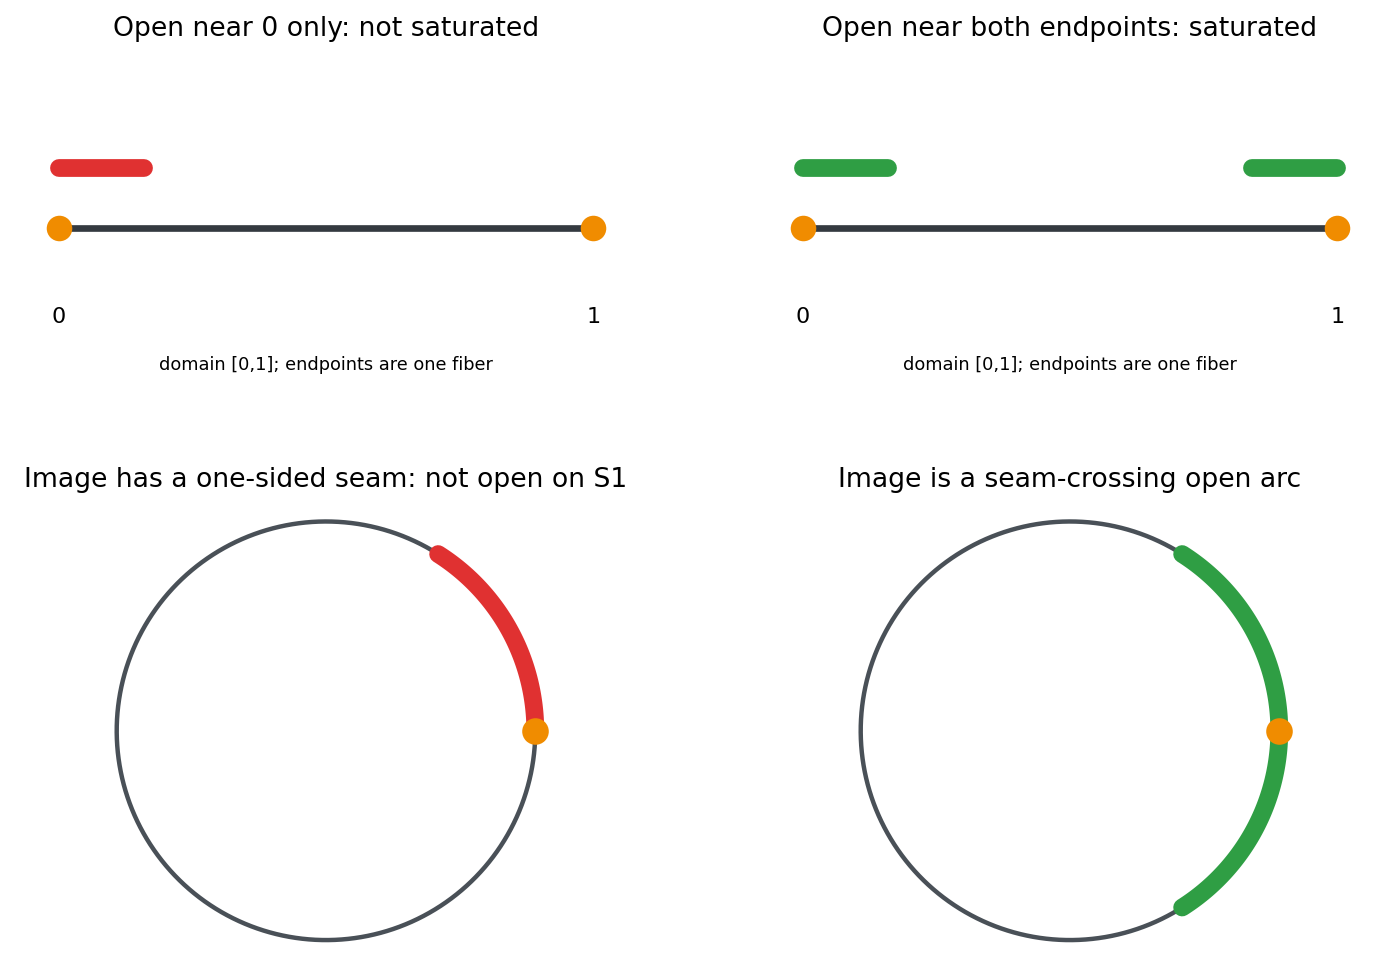

In [5]:
quotient_rows = [
    {
        "candidate": "near_left_endpoint_only",
        "interval_description": "[0, 0.16)",
        "open_in_subspace_interval": True,
        "saturated_for_endpoint_quotient": False,
        "image_open_in_circle": False,
        "reason": "contains one representative of the endpoint fiber but not the other",
    },
    {
        "candidate": "near_both_endpoints",
        "interval_description": "[0, 0.16) union (0.84, 1]",
        "open_in_subspace_interval": True,
        "saturated_for_endpoint_quotient": True,
        "image_open_in_circle": True,
        "reason": "contains the whole endpoint fiber and forms a seam-crossing arc",
    },
    {
        "candidate": "middle_arc",
        "interval_description": "(0.32, 0.68)",
        "open_in_subspace_interval": True,
        "saturated_for_endpoint_quotient": True,
        "image_open_in_circle": True,
        "reason": "no identified endpoint is involved",
    },
    {
        "candidate": "endpoint_pair_only",
        "interval_description": "{0, 1}",
        "open_in_subspace_interval": False,
        "saturated_for_endpoint_quotient": True,
        "image_open_in_circle": False,
        "reason": "saturated but too small to be open",
    },
]
quotient_table_path = save_csv(quotient_rows, TABLES / "quotient-diagnostics.csv")
table_paths.append(quotient_table_path)

quotient_checks = {
    "all_open_saturated_candidates_have_open_image": all(
        row["image_open_in_circle"]
        for row in quotient_rows
        if row["open_in_subspace_interval"] and row["saturated_for_endpoint_quotient"]
    ),
    "left_endpoint_only_flags_non_saturated": not quotient_rows[0]["saturated_for_endpoint_quotient"],
    "endpoint_pair_saturated_but_not_open": quotient_rows[3]["saturated_for_endpoint_quotient"] and not quotient_rows[3]["open_in_subspace_interval"],
    "diagnostic_rows": quotient_rows,
}
assert quotient_checks["all_open_saturated_candidates_have_open_image"]
assert quotient_checks["left_endpoint_only_flags_non_saturated"]
assert quotient_checks["endpoint_pair_saturated_but_not_open"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), gridspec_kw={"height_ratios": [1, 1.25]})
axes = axes.ravel()

def draw_interval_candidate(ax, title, segments, colors):
    ax.plot([0, 1], [0, 0], color="#343a40", lw=3)
    ax.scatter([0, 1], [0, 0], s=110, color="#f08c00", zorder=3)
    ax.text(0, -0.16, "0", ha="center")
    ax.text(1, -0.16, "1", ha="center")
    ax.text(0.5, -0.24, "domain [0,1]; endpoints are one fiber", ha="center", fontsize=8)
    for (a, b), color in zip(segments, colors):
        ax.plot([a, b], [0.1, 0.1], color=color, lw=8, solid_capstyle="round")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.32, 0.3)
    ax.set_title(title)
    ax.set_axis_off()

draw_interval_candidate(
    axes[0],
    "Open near 0 only: not saturated",
    [(0.0, 0.16)],
    ["#e03131"],
)
draw_interval_candidate(
    axes[1],
    "Open near both endpoints: saturated",
    [(0.0, 0.16), (0.84, 1.0)],
    ["#2f9e44", "#2f9e44"],
)

theta = np.linspace(0, 2 * np.pi, 400)
for ax, title, arcs, colors in [
    (axes[2], "Image has a one-sided seam: not open on S1", [(0.0, 0.32 * np.pi)], ["#e03131"]),
    (axes[3], "Image is a seam-crossing open arc", [(0.0, 0.32 * np.pi), (1.68 * np.pi, 2 * np.pi)], ["#2f9e44", "#2f9e44"]),
]:
    ax.plot(np.cos(theta), np.sin(theta), color="#495057", lw=2)
    ax.scatter([1], [0], s=120, color="#f08c00", zorder=3)
    for (a, b), color in zip(arcs, colors):
        th = np.linspace(a, b, 100)
        ax.plot(np.cos(th), np.sin(th), color=color, lw=8, solid_capstyle="round")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_axis_off()

quotient_diag_path = save_matplotlib(fig, FIGURES / "quotient-saturated-open-diagnostics.png")
plt.close(fig)
artifact_paths.append(quotient_diag_path)
quotient_checks_path = save_json(quotient_checks, CHECKS / "quotient-map-checks.json")
check_paths.append(quotient_checks_path)

display(pd.DataFrame(quotient_rows))
display_artifact(quotient_diag_path, width=840)


## Connected, Path-Connected, and Locally Path-Connected Models

Connectedness forbids a separation by two open pieces. Path-connectedness asks for actual paths between points. The appendix emphasizes that local path-connectedness is the bridge between these ideas: in that setting, components are open and path components equal components.

Graphs are not arbitrary topological spaces, but as one-dimensional CW-like models they are locally path-connected. Their components are therefore a good computational stand-in for path components in familiar manifold examples.


,split_component_count,bridge_component_count,path_connected_graph_is_connected,product_of_connected_graphs_connected,quotient_of_connected_graph_connected,split_components,bridge_components
0,2,1,True,True,True,"[[a0, a1, a2], [b0, b1, b2]]","[[a0, a1, a2, b0, b1, b2]]"


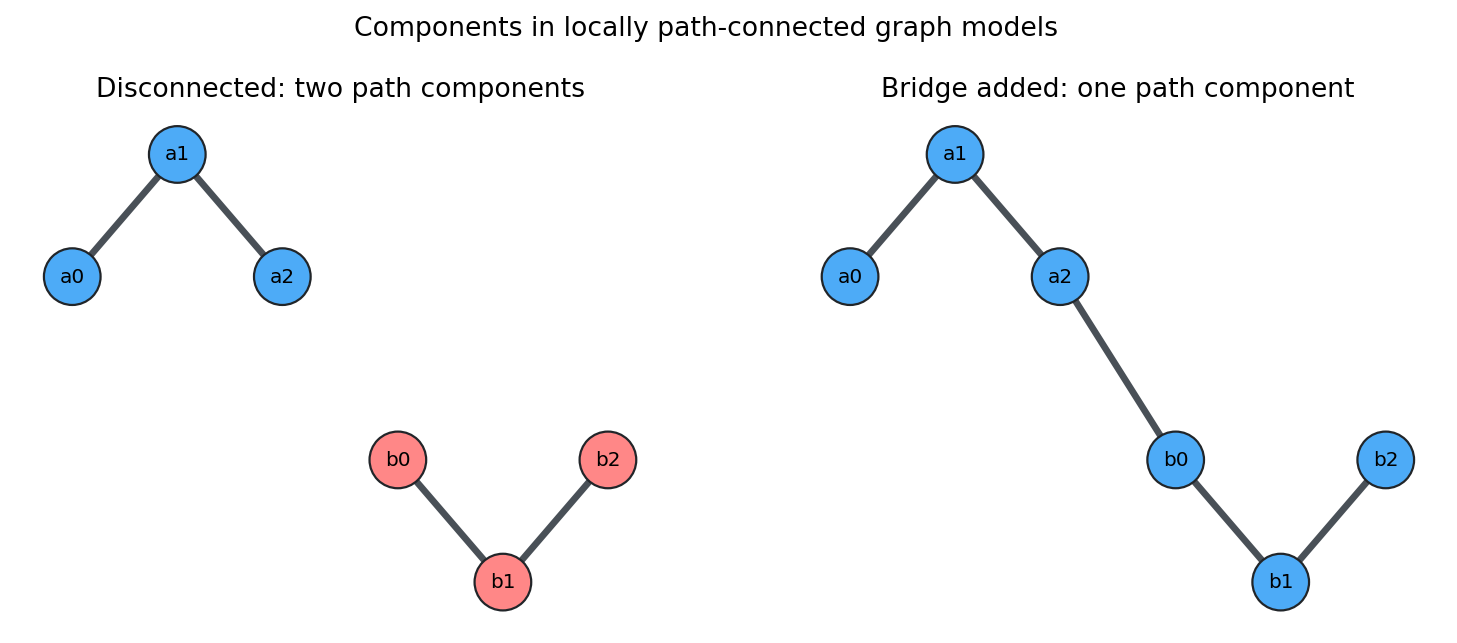

In [6]:
G_split = nx.Graph()
G_split.add_edges_from([("a0", "a1"), ("a1", "a2"), ("b0", "b1"), ("b1", "b2")])

G_bridge = G_split.copy()
G_bridge.add_edge("a2", "b0")

P3 = nx.path_graph(3)
P2 = nx.path_graph(2)
product_graph = nx.cartesian_product(P3, P2)

quotient_graph = nx.contracted_nodes(G_bridge.copy(), "a0", "b2", self_loops=False)

component_checks = {
    "split_component_count": nx.number_connected_components(G_split),
    "bridge_component_count": nx.number_connected_components(G_bridge),
    "path_connected_graph_is_connected": nx.is_connected(G_bridge),
    "product_of_connected_graphs_connected": nx.is_connected(product_graph),
    "quotient_of_connected_graph_connected": nx.is_connected(quotient_graph),
    "split_components": [sorted(c) for c in nx.connected_components(G_split)],
    "bridge_components": [sorted(c) for c in nx.connected_components(G_bridge)],
}
assert component_checks["split_component_count"] == 2
assert component_checks["bridge_component_count"] == 1
assert component_checks["product_of_connected_graphs_connected"]
assert component_checks["quotient_of_connected_graph_connected"]

positions = {
    "a0": (0, 0.15),
    "a1": (1, 0.35),
    "a2": (2, 0.15),
    "b0": (3.1, -0.15),
    "b1": (4.1, -0.35),
    "b2": (5.1, -0.15),
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, graph, title in [
    (axes[0], G_split, "Disconnected: two path components"),
    (axes[1], G_bridge, "Bridge added: one path component"),
]:
    comps = list(nx.connected_components(graph))
    color_by_node = {}
    palette = ["#4dabf7", "#ff8787", "#69db7c"]
    for idx, comp in enumerate(comps):
        for node in comp:
            color_by_node[node] = palette[idx % len(palette)]
    nx.draw_networkx_edges(graph, positions, ax=ax, width=3, edge_color="#495057")
    nx.draw_networkx_nodes(
        graph,
        positions,
        ax=ax,
        node_color=[color_by_node[n] for n in graph.nodes],
        edgecolors="#212529",
        node_size=650,
    )
    nx.draw_networkx_labels(graph, positions, ax=ax, font_size=9)
    ax.set_title(title)
    ax.set_axis_off()
fig.suptitle("Components in locally path-connected graph models", y=1.02)

connected_path = save_matplotlib(fig, FIGURES / "connectedness-components-graph.png")
plt.close(fig)
artifact_paths.append(connected_path)

component_checks_path = save_json(component_checks, CHECKS / "connectedness-checks.json")
check_paths.append(component_checks_path)

display(pd.DataFrame([component_checks]))
display_artifact(connected_path, width=840)


## Compactness, Proper Maps, and Local Compactness

Compactness is a finite-certificate principle: every open cover has a finite subcover. In metric spaces that later appear in the book, compactness can also be detected by sequential behavior, but the open-cover definition is the one that works in full generality.

Properness is the map version of compact control: compact sets in the target pull back to compact sets in the source. Local compactness asks for compact control near each point; with second-countability it gives compact exhaustions.


,cover_set,left,right,selected_in_subcover
0,U1,-0.08,0.18,True
1,U2,0.12,0.36,True
2,U3,0.30,0.55,True
3,U4,0.48,0.72,True
4,U5,0.66,0.90,True
5,U6,0.84,1.08,True


,n,K_n,K_n_compact_in_R,contained_in_interior_K_next
0,1,"[-1, 1]",True,True
1,2,"[-2, 2]",True,True
2,3,"[-3, 3]",True,True
3,4,"[-4, 4]",True,True


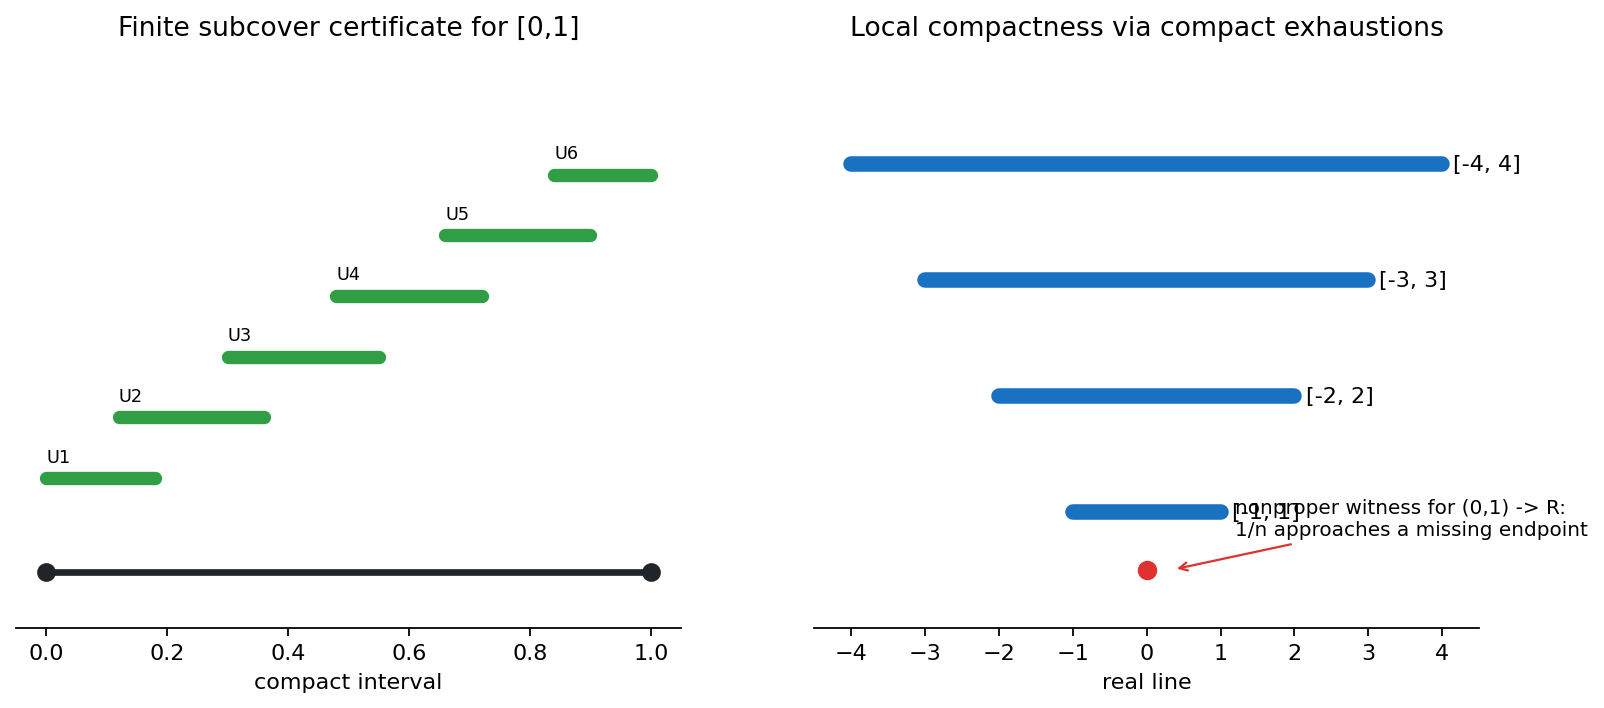

In [7]:
cover_intervals = [
    (-0.08, 0.18),
    (0.12, 0.36),
    (0.30, 0.55),
    (0.48, 0.72),
    (0.66, 0.90),
    (0.84, 1.08),
]

grid = np.linspace(0, 1, 501)

def covered_by(intervals, points):
    mask = np.zeros_like(points, dtype=bool)
    for a, b in intervals:
        mask |= (a < points) & (points < b)
    return mask

def greedy_subcover(intervals):
    selected = []
    current = 0.0
    remaining = sorted(intervals)
    while current < 1.0 - 1e-12:
        candidates = [iv for iv in remaining if iv[0] < current + 1e-12 and iv[1] > current]
        if not candidates:
            raise RuntimeError("cover gap")
        best = max(candidates, key=lambda iv: iv[1])
        selected.append(best)
        current = min(best[1], 1.0)
        remaining.remove(best)
    return selected

selected_intervals = greedy_subcover(cover_intervals)
all_cover_mask = covered_by(cover_intervals, grid)
selected_cover_mask = covered_by(selected_intervals, grid)

exhaustion_rows = []
for n in range(1, 5):
    exhaustion_rows.append({
        "n": n,
        "K_n": f"[-{n}, {n}]",
        "K_n_compact_in_R": True,
        "contained_in_interior_K_next": True,
    })

compact_rows = []
for idx, interval in enumerate(cover_intervals, start=1):
    compact_rows.append({
        "cover_set": f"U{idx}",
        "left": interval[0],
        "right": interval[1],
        "selected_in_subcover": interval in selected_intervals,
    })

compact_table_path = save_csv(compact_rows, TABLES / "compact-cover-ledger.csv")
table_paths.append(compact_table_path)

nonproper_witness = {
    "map": "inclusion (0,1) -> R",
    "compact_target_set": "[0,1]",
    "preimage": "(0,1)",
    "sequence": "1/n",
    "limit_in_target": 0,
    "limit_in_source": False,
    "therefore_preimage_not_compact_metric_evidence": True,
}

compact_checks = {
    "original_cover_covers_grid": bool(all_cover_mask.all()),
    "selected_subcover_covers_grid": bool(selected_cover_mask.all()),
    "cover_size": len(cover_intervals),
    "selected_subcover_size": len(selected_intervals),
    "selected_subcover": selected_intervals,
    "compact_domain_to_hausdorff_target_proper_principle": True,
    "closed_embedding_with_closed_image_proper_principle": True,
    "nonproper_open_interval_inclusion_witness": nonproper_witness,
    "compact_exhaustion_R_first_four": exhaustion_rows,
    "exhaustion_nesting_checked": all(row["contained_in_interior_K_next"] for row in exhaustion_rows),
}
assert compact_checks["original_cover_covers_grid"]
assert compact_checks["selected_subcover_covers_grid"]
assert compact_checks["selected_subcover_size"] <= compact_checks["cover_size"]
assert compact_checks["nonproper_open_interval_inclusion_witness"]["therefore_preimage_not_compact_metric_evidence"]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.7))
ax = axes[0]
ax.plot([0, 1], [0, 0], color="#212529", lw=3)
ax.scatter([0, 1], [0, 0], color="#212529", s=55, zorder=3)
for idx, (a, b) in enumerate(cover_intervals):
    y = 0.2 + 0.13 * idx
    color = "#2f9e44" if (a, b) in selected_intervals else "#adb5bd"
    lw = 6 if (a, b) in selected_intervals else 3
    ax.plot([max(a, 0), min(b, 1)], [y, y], color=color, lw=lw, solid_capstyle="round")
    ax.text(max(a, 0), y + 0.035, f"U{idx+1}", fontsize=8)
ax.set_title("Finite subcover certificate for [0,1]")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.12, 1.12)
ax.set_yticks([])
ax.set_xlabel("compact interval")
ax.spines[["left", "right", "top"]].set_visible(False)

ax = axes[1]
for n, row in enumerate(exhaustion_rows, start=1):
    ax.plot([-n, n], [n, n], color="#1971c2", lw=7, solid_capstyle="round")
    ax.text(n + 0.15, n, row["K_n"], va="center")
ax.scatter([0], [0.5], color="#e03131", s=60)
ax.annotate(
    "nonproper witness for (0,1) -> R:\n1/n approaches a missing endpoint",
    xy=(0.35, 0.5),
    xytext=(1.2, 0.8),
    arrowprops={"arrowstyle": "->", "color": "#e03131"},
    fontsize=9,
)
ax.set_title("Local compactness via compact exhaustions")
ax.set_ylim(0, 5)
ax.set_xlim(-4.5, 4.5)
ax.set_yticks([])
ax.set_xlabel("real line")
ax.spines[["left", "right", "top"]].set_visible(False)

compact_path = save_matplotlib(fig, FIGURES / "compactness-finite-subcover-model.png")
plt.close(fig)
artifact_paths.append(compact_path)

compact_checks_path = save_json(compact_checks, CHECKS / "compactness-properness-checks.json")
check_paths.append(compact_checks_path)

display(pd.DataFrame(compact_rows))
display(pd.DataFrame(exhaustion_rows))
display_artifact(compact_path, width=860)


## Homotopy, Fundamental Groups, and Covering Maps

For a loop in the circle, path homotopy preserves the winding number. The universal cover `R -> S1`, `theta |-> exp(i theta)`, makes this visible: lift the loop to the line, and the endpoint displacement is an integer.

For the finite cover `S1 -> S1`, `z |-> z^n`, a base loop of winding `k` lifts to a closed loop exactly when `k` is a multiple of `n`. This is the lifting criterion in a computable form: the induced subgroup is `nZ` inside `Z`.


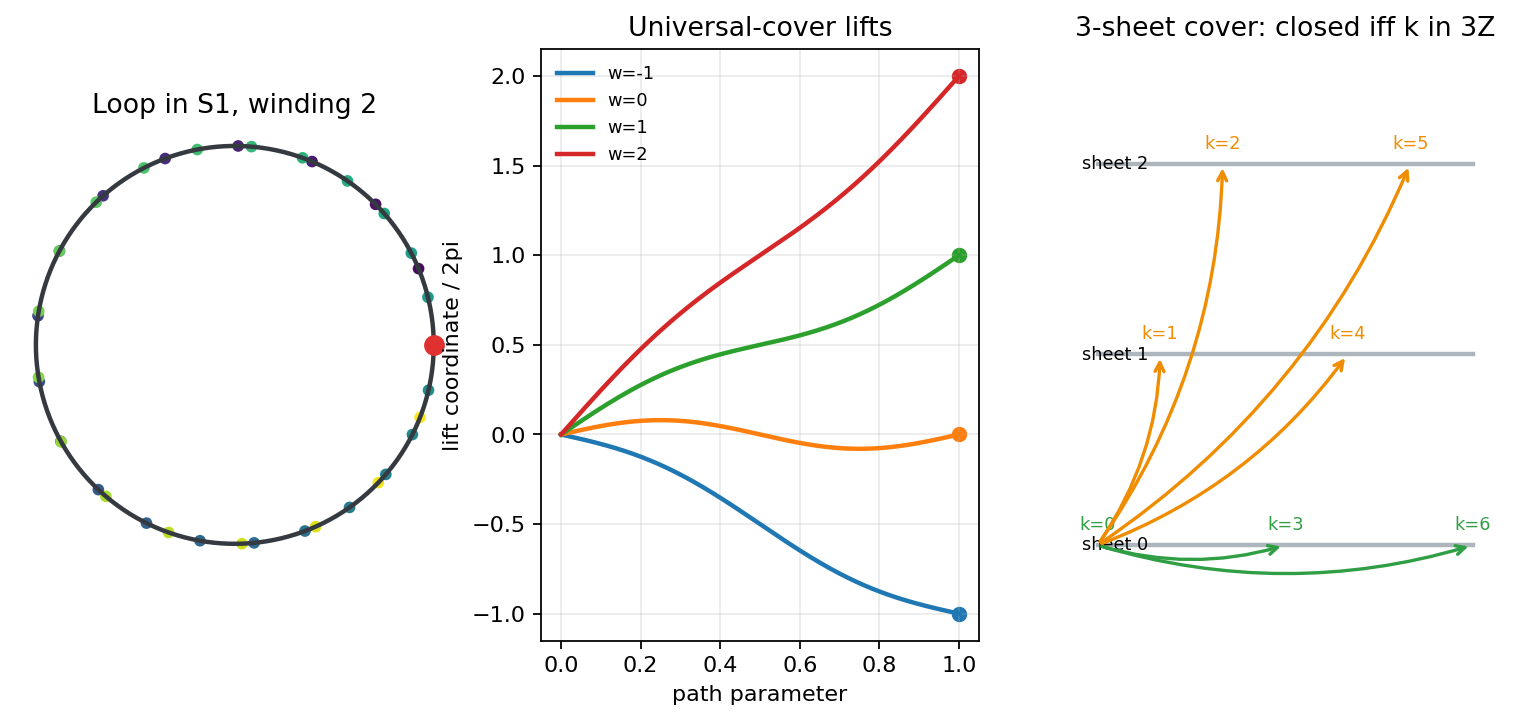

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


`fundamental-group-covering-checks.json`: `{'computed_windings': {'-1': -1, '0': 0, '1': 1, '2': 2}, 'product_winding_1_plus_2': 3, 'expected_product_winding_3': 3, 'reverse_loop_winding_of_2': -2, 'three_sheet_cover_closed_lift': {'0': True, '1': False, '2': False, '3': True, '4': False, '5': False, '6': True}, 'additivity_checked': True, 'reverse_checked': True, 'cover_projection_residual': 9.550499576785472e-16, 'cover_projection_residual_below_tolerance': True}`

In [8]:
def lifted_angle(t_values, winding: int, wiggle: float = 0.08):
    t_values = np.asarray(t_values)
    return 2 * np.pi * (winding * t_values + wiggle * np.sin(2 * np.pi * t_values))

def winding_from_lift(theta_values) -> int:
    return int(round((theta_values[-1] - theta_values[0]) / (2 * np.pi)))

t_vals = np.linspace(0, 1, 800)
windings = [-1, 0, 1, 2]
lift_data = {k: lifted_angle(t_vals, k) for k in windings}

winding_checks = {
    "computed_windings": {str(k): winding_from_lift(theta) for k, theta in lift_data.items()},
    "product_winding_1_plus_2": winding_from_lift(lifted_angle(t_vals, 1)) + winding_from_lift(lifted_angle(t_vals, 2)),
    "expected_product_winding_3": 3,
    "reverse_loop_winding_of_2": -winding_from_lift(lifted_angle(t_vals, 2)),
    "three_sheet_cover_closed_lift": {str(k): (k % 3 == 0) for k in range(0, 7)},
}
winding_checks["additivity_checked"] = winding_checks["product_winding_1_plus_2"] == winding_checks["expected_product_winding_3"]
winding_checks["reverse_checked"] = winding_checks["reverse_loop_winding_of_2"] == -2

theta_path = lifted_angle(t_vals, 2)
projected = np.column_stack([np.cos(theta_path), np.sin(theta_path)])
base_recomputed = np.column_stack([np.cos(np.unwrap(np.arctan2(projected[:, 1], projected[:, 0]))), np.sin(np.unwrap(np.arctan2(projected[:, 1], projected[:, 0])))])
projection_residual = float(np.max(np.linalg.norm(projected - base_recomputed, axis=1)))
winding_checks["cover_projection_residual"] = projection_residual
winding_checks["cover_projection_residual_below_tolerance"] = projection_residual < 1e-12

assert winding_checks["computed_windings"] == {"-1": -1, "0": 0, "1": 1, "2": 2}
assert winding_checks["additivity_checked"]
assert winding_checks["reverse_checked"]
assert winding_checks["three_sheet_cover_closed_lift"]["3"]
assert not winding_checks["three_sheet_cover_closed_lift"]["1"]
assert winding_checks["cover_projection_residual_below_tolerance"]

fig = plt.figure(figsize=(12, 4.8))
ax1 = fig.add_subplot(1, 3, 1)
theta = np.linspace(0, 2 * np.pi, 500)
ax1.plot(np.cos(theta), np.sin(theta), color="#343a40", lw=2)
theta_loop = lifted_angle(t_vals, 2)
ax1.scatter(np.cos(theta_loop[::20]), np.sin(theta_loop[::20]), c=t_vals[::20], cmap="viridis", s=18)
ax1.scatter([1], [0], color="#e03131", s=70, zorder=4)
ax1.set_title("Loop in S1, winding 2")
ax1.set_aspect("equal")
ax1.set_axis_off()

ax2 = fig.add_subplot(1, 3, 2)
for k, theta_values in lift_data.items():
    ax2.plot(t_vals, theta_values / (2 * np.pi), lw=2, label=f"w={k}")
    ax2.scatter([1], [theta_values[-1] / (2 * np.pi)], s=35)
ax2.set_title("Universal-cover lifts")
ax2.set_xlabel("path parameter")
ax2.set_ylabel("lift coordinate / 2pi")
ax2.legend(frameon=False, fontsize=8)
ax2.grid(alpha=0.25)

ax3 = fig.add_subplot(1, 3, 3)
n_sheets = 3
for sheet in range(n_sheets):
    ax3.plot([0, 6], [sheet, sheet], color="#adb5bd", lw=2)
    ax3.text(-0.25, sheet, f"sheet {sheet}", va="center", fontsize=8)
for k in range(0, 7):
    start_sheet = 0
    end_sheet = k % n_sheets
    color = "#2f9e44" if end_sheet == start_sheet else "#f08c00"
    ax3.annotate(
        "",
        xy=(k, end_sheet),
        xytext=(0, start_sheet),
        arrowprops={"arrowstyle": "->", "color": color, "lw": 1.5, "connectionstyle": "arc3,rad=0.15"},
    )
    ax3.text(k, end_sheet + 0.08, f"k={k}", ha="center", fontsize=8, color=color)
ax3.set_xlim(-0.5, 6.5)
ax3.set_ylim(-0.5, 2.6)
ax3.set_title("3-sheet cover: closed iff k in 3Z")
ax3.set_xticks([])
ax3.set_yticks([])
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)

winding_path = save_matplotlib(fig, FIGURES / "loop-winding-and-covering-lift.png")
plt.close(fig)
artifact_paths.append(winding_path)

helix_theta = np.linspace(-2 * np.pi, 6 * np.pi, 700)
path_theta = lifted_angle(t_vals, 2)
fig_plotly = go.Figure()
fig_plotly.add_trace(go.Scatter3d(
    x=np.cos(helix_theta),
    y=np.sin(helix_theta),
    z=helix_theta / (2 * np.pi),
    mode="lines",
    name="universal cover helix",
    line={"color": "#868e96", "width": 4},
))
fig_plotly.add_trace(go.Scatter3d(
    x=np.cos(path_theta),
    y=np.sin(path_theta),
    z=path_theta / (2 * np.pi),
    mode="lines",
    name="lift of winding-2 loop",
    line={"color": "#1971c2", "width": 7},
))
fig_plotly.add_trace(go.Scatter3d(
    x=[1, 1],
    y=[0, 0],
    z=[0, 2],
    mode="markers+text",
    text=["start", "end"],
    textposition="top center",
    name="lift endpoints",
    marker={"size": 5, "color": "#e03131"},
))
fig_plotly.update_layout(
    title="Universal cover R -> S1: lifted endpoint displacement records winding",
    scene={
        "xaxis_title": "cos(theta)",
        "yaxis_title": "sin(theta)",
        "zaxis_title": "theta / 2pi",
        "aspectmode": "manual",
        "aspectratio": {"x": 1, "y": 1, "z": 1.6},
    },
    margin={"l": 0, "r": 0, "t": 45, "b": 0},
    height=650,
)
covering_html_path = save_plotly_html(fig_plotly, HTML / "circle-covering-lift-simulator.html")
artifact_paths.append(covering_html_path)

winding_checks_path = save_json(winding_checks, CHECKS / "fundamental-group-covering-checks.json")
check_paths.append(winding_checks_path)

display_artifact(winding_path, width=880)
display_artifact(covering_html_path, width=880, height=620)
display(Markdown(f"`fundamental-group-covering-checks.json`: `{winding_checks}`"))


## Applied Lab: Diagnose a Proposed Manifold-Building Step

When a construction appears later in the book, run this checklist before asking for smooth structure:

1. What are the open sets, or what map defines them?
2. Is the map continuous by inverse-image tests?
3. If a quotient is involved, are the sets being projected saturated?
4. Which hypotheses are being used: Hausdorff, second-countable, locally path-connected, locally compact?
5. Which invariant should survive the construction: components, compactness, pi_1, or covering sheets?

The small diagnostic table below compares common moves from Appendix A.


In [9]:
lab_rows = [
    {
        "construction": "open subspace U of X",
        "continuity_test": "compose with inclusion U -> X",
        "hypothesis_to_check": "subspace topology",
        "common_failure": "calling relatively open sets open in X",
        "invariant_or_result": "Hausdorff and countability pass to subspaces",
    },
    {
        "construction": "finite product X x Y",
        "continuity_test": "check both component maps",
        "hypothesis_to_check": "product topology",
        "common_failure": "forgetting product-open sets form a basis, not all opens",
        "invariant_or_result": "connected, compact, Hausdorff, countability preserved for finite products",
    },
    {
        "construction": "quotient X/~",
        "continuity_test": "precompose with projection q: X -> X/~",
        "hypothesis_to_check": "surjective continuous quotient map",
        "common_failure": "projecting non-saturated open sets and expecting opens",
        "invariant_or_result": "connectedness and compactness pass to quotients",
    },
    {
        "construction": "covering map E -> X",
        "continuity_test": "evenly covered neighborhoods",
        "hypothesis_to_check": "connected and locally path-connected spaces",
        "common_failure": "ignoring lift starting point",
        "invariant_or_result": "path lifting, monodromy, universal cover when locally simply connected",
    },
    {
        "construction": "proper map F: X -> Y",
        "continuity_test": "compact preimages",
        "hypothesis_to_check": "target locally compact Hausdorff for closed-map theorem",
        "common_failure": "assuming every closed embedding is proper without closed image",
        "invariant_or_result": "proper continuous maps to locally compact Hausdorff targets are closed",
    },
]
lab_path = save_csv(lab_rows, TABLES / "topology-construction-diagnostic-lab.csv")
table_paths.append(lab_path)
display(pd.DataFrame(lab_rows))


,construction,continuity_test,hypothesis_to_check,common_failure,invariant_or_result
0,open subspace U of X,compose with inclusion U -> X,subspace topology,calling relatively open sets open in X,Hausdorff and countability pass to subspaces
1,finite product X x Y,check both component maps,product topology,"forgetting product-open sets form a basis, not...","connected, compact, Hausdorff, countability pr..."
2,quotient X/~,precompose with projection q: X -> X/~,surjective continuous quotient map,projecting non-saturated open sets and expecti...,connectedness and compactness pass to quotients
3,covering map E -> X,evenly covered neighborhoods,connected and locally path-connected spaces,ignoring lift starting point,"path lifting, monodromy, universal cover when ..."
4,proper map F: X -> Y,compact preimages,target locally compact Hausdorff for closed-ma...,assuming every closed embedding is proper with...,proper continuous maps to locally compact Haus...


## Final Sanity Checks

These checks assert that the notebook produced the promised artifacts and that the core Appendix A models actually validate the intended identities.


In [10]:
expected_artifacts = [
    FIGURES / "topology-operations-lattice.png",
    FIGURES / "topology-constructions-flow.png",
    FIGURES / "quotient-saturated-open-diagnostics.png",
    FIGURES / "connectedness-components-graph.png",
    FIGURES / "compactness-finite-subcover-model.png",
    FIGURES / "loop-winding-and-covering-lift.png",
    HTML / "circle-covering-lift-simulator.html",
    TABLES / "library-routing.csv",
    TABLES / "finite-topology-sets.csv",
    TABLES / "quotient-diagnostics.csv",
    TABLES / "compact-cover-ledger.csv",
    TABLES / "topology-construction-diagnostic-lab.csv",
    CHECKS / "visual-storyboard.json",
    CHECKS / "finite-topology-checks.json",
    CHECKS / "construction-topology-checks.json",
    CHECKS / "quotient-map-checks.json",
    CHECKS / "connectedness-checks.json",
    CHECKS / "compactness-properness-checks.json",
    CHECKS / "fundamental-group-covering-checks.json",
]
assert_artifacts(expected_artifacts, min_bytes=64)

finite_loaded = json.loads((CHECKS / "finite-topology-checks.json").read_text(encoding="utf-8"))
quotient_loaded = json.loads((CHECKS / "quotient-map-checks.json").read_text(encoding="utf-8"))
connected_loaded = json.loads((CHECKS / "connectedness-checks.json").read_text(encoding="utf-8"))
compact_loaded = json.loads((CHECKS / "compactness-properness-checks.json").read_text(encoding="utf-8"))
covering_loaded = json.loads((CHECKS / "fundamental-group-covering-checks.json").read_text(encoding="utf-8"))

assert finite_loaded["topology_axioms_hold"]
assert finite_loaded["boundary_equals_closure_intersection_complement_closure"]
assert finite_loaded["nonhausdorff_example"]
assert quotient_loaded["all_open_saturated_candidates_have_open_image"]
assert connected_loaded["bridge_component_count"] == 1
assert compact_loaded["selected_subcover_covers_grid"]
assert covering_loaded["additivity_checked"]
assert covering_loaded["cover_projection_residual_below_tolerance"]

source_coverage = {
    "source_span": "Appendix A, printed pages 596-616",
    "anchors_covered": {
        "topological_spaces_open_closed_interior_closure_boundary": True,
        "continuous_maps_and_sequences": True,
        "hausdorff_second_countable_local_properties": True,
        "subspace_product_disjoint_union_quotient_topology_and_quotient_maps": True,
        "connected_path_connected_local_path_connected": True,
        "compactness_proper_maps_local_compactness": True,
        "homotopy_fundamental_group": True,
        "covering_maps_lifting_universal_covers": True,
    },
}
source_coverage_path = save_json(source_coverage, CHECKS / "source-coverage.json")

final_sanity = {
    "artifact_count": len(expected_artifacts),
    "total_artifact_bytes": sum(path.stat().st_size for path in expected_artifacts),
    "figures": [path.name for path in expected_artifacts if path.suffix == ".png"],
    "html": [path.name for path in expected_artifacts if path.suffix == ".html"],
    "tables": [path.name for path in expected_artifacts if path.suffix == ".csv"],
    "checks": [path.name for path in expected_artifacts if path.suffix == ".json"] + [source_coverage_path.name],
    "obsolete_generic_scaffold_remaining": sorted(path.name for path in ARTIFACT_ROOT.rglob("review-of-topology-*")),
    "core_validations": {
        "finite_topology": finite_loaded["topology_axioms_hold"],
        "boundary_identity": finite_loaded["boundary_equals_closure_intersection_complement_closure"],
        "quotient_saturation": quotient_loaded["all_open_saturated_candidates_have_open_image"],
        "connectedness": connected_loaded["bridge_component_count"] == 1,
        "compact_subcover": compact_loaded["selected_subcover_covers_grid"],
        "covering_lift": covering_loaded["cover_projection_residual_below_tolerance"],
    },
}
assert final_sanity["obsolete_generic_scaffold_remaining"] == []
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert_artifacts([source_coverage_path, final_sanity_path], min_bytes=64)

display(Markdown("Final sanity checks passed."))
display(pd.DataFrame([final_sanity["core_validations"]]))
display(Markdown(f"Generated `{final_sanity['artifact_count']}` required artifacts with `{final_sanity['total_artifact_bytes']}` bytes before final summaries."))


Final sanity checks passed.

,finite_topology,boundary_identity,quotient_saturation,connectedness,compact_subcover,covering_lift
0,True,True,True,True,True,True


Generated `19` required artifacts with `646537` bytes before final summaries.

## Takeaways

- Open sets are the primitive data; closed sets, interior, closure, exterior, and boundary are derived operations.
- Continuity is a backward test on open sets, which is why construction topologies are described by characteristic properties.
- Hausdorff, countability, local path-connectedness, and local compactness are not decorative assumptions; they turn wild topology into the setting where manifold arguments behave geometrically.
- Quotient maps must be read through saturated subsets and the quotient projection.
- Compactness turns infinite-looking cover data into finite certificates and supports closed-map/proper-map arguments.
- The fundamental group records homotopy classes of loops, and covering maps make those classes visible through unique lifts and sheet changes.
